# Семинар 8. Transformer OCR

https://huggingface.co/docs/transformers/model_doc/trocr

## Задание 1

Запустите распознавание собственного документа и сравните результат с EasyOCR из 7 лабораторной.

In [1]:
import contextlib
import io
import os
import re
import time
import unicodedata
from pathlib import Path

import easyocr
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

try:
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
except Exception:
    pass

In [2]:
TROCR_MODEL_ID = "raxtemur/trocr-base-ru"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    processor = TrOCRProcessor.from_pretrained(TROCR_MODEL_ID)
    model = VisionEncoderDecoderModel.from_pretrained(TROCR_MODEL_ID).to(DEVICE)

model.eval()
model.config.use_cache = True

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

In [3]:
def load_pdf_first_page(path, dpi=220):
    import fitz

    with fitz.open(path) as doc:
        page = doc.load_page(0)
        zoom = dpi / 72
        pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), alpha=False)
        return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)


def normalize_ocr_text(text):
    text = unicodedata.normalize("NFKC", text).lower()
    text = text.replace("ё", "е")
    text = re.sub(r"[«»“”]", '"', text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def levenshtein_distance(a, b):
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        current = [i]
        for j, cb in enumerate(b, 1):
            current.append(min(
                current[j - 1] + 1,
                previous[j] + 1,
                previous[j - 1] + (ca != cb),
            ))
        previous = current
    return previous[-1]


def text_metrics(predicted, expected):
    pred_norm = normalize_ocr_text(predicted)
    exp_norm = normalize_ocr_text(expected)
    char_distance = levenshtein_distance(pred_norm, exp_norm)
    cer = char_distance / max(1, len(exp_norm))

    pred_words = pred_norm.split()
    exp_words = exp_norm.split()
    word_distance = levenshtein_distance(pred_words, exp_words)
    wer = word_distance / max(1, len(exp_words))

    return {
        "char_accuracy": max(0.0, 1.0 - cer),
        "word_accuracy": max(0.0, 1.0 - wer),
        "cer": cer,
        "wer": wer,
    }


def sort_detections_reading_order(detections):
    return sorted(
        detections,
        key=lambda item: (
            min(point[1] for point in item[0]),
            min(point[0] for point in item[0]),
        ),
    )


def crop_ocr_bbox(image, detection, padding=8):
    points = detection[0]
    xs = [point[0] for point in points]
    ys = [point[1] for point in points]
    left = max(0, int(min(xs)) - padding)
    top = max(0, int(min(ys)) - padding)
    right = min(image.width, int(max(xs)) + padding)
    bottom = min(image.height, int(max(ys)) + padding)
    return image.crop((left, top, right, bottom))


def easyocr_text(detections):
    return "\n".join(text for _, text, _ in detections)


def trocr_recognize_crop(image):
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(DEVICE)
    with torch.no_grad():
        output = model.generate(
            pixel_values,
            max_new_tokens=96,
            return_dict_in_generate=True,
            output_scores=True,
        )

    text = processor.batch_decode(output.sequences, skip_special_tokens=True)[0].strip()

    if output.scores:
        token_ids = output.sequences[:, -len(output.scores):][0]
        token_probs = []
        for step_scores, token_id in zip(output.scores, token_ids):
            probs = torch.softmax(step_scores[0], dim=-1)
            token_probs.append(float(probs[token_id].detach().cpu()))
        confidence = float(np.mean(token_probs)) if token_probs else np.nan
    else:
        confidence = np.nan

    return text, confidence


def trocr_recognize_detections(image, detections):
    rows = []
    for detection in detections:
        crop = crop_ocr_bbox(image, detection)
        text, confidence = trocr_recognize_crop(crop)
        if not text:
            text = detection[1]
        rows.append(
            {
                "bbox": detection[0],
                "text": text,
                "trocr_confidence": confidence,
                "detector_confidence": float(detection[2]),
            }
        )
    return rows


def trocr_text(rows):
    return "\n".join(row["text"] for row in rows)


def visualize_easyocr_result(image, detections, title):
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    for bbox, text, conf in detections:
        points = np.array(bbox)
        color = "lime" if conf >= 0.8 else "orange" if conf >= 0.5 else "red"
        ax.add_patch(plt.Polygon(points, fill=False, edgecolor=color, linewidth=2))

        x, y = points[0]
        ax.text(
            x,
            max(0, y - 8),
            f"{text} ({conf:.2f})",
            fontsize=9,
            color="black",
            bbox=dict(facecolor=color, alpha=0.75, edgecolor="none", pad=2),
        )

    plt.tight_layout()
    plt.show()


def visualize_trocr_result(image, rows, title):
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    for row in rows:
        points = np.array(row["bbox"])
        conf = row["trocr_confidence"]
        color = "lime" if conf >= 0.8 else "orange" if conf >= 0.5 else "red"
        ax.add_patch(plt.Polygon(points, fill=False, edgecolor=color, linewidth=2))

        x, y = points[0]
        label = f"{row['text']} ({conf:.2f})" if not np.isnan(conf) else row["text"]
        ax.text(
            x,
            max(0, y - 8),
            label,
            fontsize=9,
            color="black",
            bbox=dict(facecolor=color, alpha=0.75, edgecolor="none", pad=2),
        )

    plt.tight_layout()
    plt.show()


In [4]:
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    easyocr_reader = easyocr.Reader(["ru", "en"], gpu=False)

## Сравнение на документе `document.jpg`

In [5]:
document_path = Path("data/document.jpg")
document_image = Image.open(document_path).convert("RGB")
document_file_size_kb = os.path.getsize(document_path) / 1024

expected_document_text = """
ДОГОВОР №123
г. Москва 01.01.2024
ООО "Технолоджи" в лице директора Иванова И.И.
и ООО "Поставщик" в лице директора Петрова П.П.
заключили настоящий договор о нижеследующем:
1. ПРЕДМЕТ ДОГОВОРА
1.1. Поставщик обязуется поставить товар.
1.2. Сумма договора: 1 500 000 рублей.
Подписи сторон:
Иванов И.И.
Петров П.П.
""".strip()

In [6]:
document_easyocr_start = time.perf_counter()
document_easyocr_detections = easyocr_reader.readtext(
    np.array(document_image),
    detail=1,
    paragraph=False,
)
document_easyocr_time = time.perf_counter() - document_easyocr_start
document_easyocr_detections = sort_detections_reading_order(document_easyocr_detections)
document_easyocr_text = easyocr_text(document_easyocr_detections)

C:\Users\selin\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [7]:
document_trocr_start = time.perf_counter()
document_trocr_rows = trocr_recognize_detections(document_image, document_easyocr_detections)
document_trocr_time = time.perf_counter() - document_trocr_start
document_trocr_text = trocr_text(document_trocr_rows)

[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

In [8]:
document_easyocr_metrics = text_metrics(document_easyocr_text, expected_document_text)
document_trocr_metrics = text_metrics(document_trocr_text, expected_document_text)

print("Сравнение моделей на document.jpg")
print(f"Размер изображения: {document_image.width}x{document_image.height}px")
print(f"Размер файла: {document_file_size_kb:.1f} KB")
print()
print("Модель                 Объекты  Время,с  CharAcc  WordAcc     CER     WER")
print(
    f"EasyOCR ru+en          {len(document_easyocr_detections):7d} "
    f"{document_easyocr_time:8.2f} "
    f"{document_easyocr_metrics['char_accuracy']:8.2%} "
    f"{document_easyocr_metrics['word_accuracy']:8.2%} "
    f"{document_easyocr_metrics['cer']:7.2%} "
    f"{document_easyocr_metrics['wer']:7.2%}"
)
print(
    f"TrOCR RU + EasyOCR box {len(document_trocr_rows):7d} "
    f"{document_easyocr_time + document_trocr_time:8.2f} "
    f"{document_trocr_metrics['char_accuracy']:8.2%} "
    f"{document_trocr_metrics['word_accuracy']:8.2%} "
    f"{document_trocr_metrics['cer']:7.2%} "
    f"{document_trocr_metrics['wer']:7.2%}"
)

Сравнение моделей на document.jpg
Размер изображения: 800x600px
Размер файла: 41.5 KB

Модель                 Объекты  Время,с  CharAcc  WordAcc     CER     WER
EasyOCR ru+en               16     2.14   86.67%   67.39%  13.33%  32.61%
TrOCR RU + EasyOCR box      16    68.93   84.13%   60.87%  15.87%  39.13%


In [9]:
print("EasyOCR:")
print(document_easyocr_text or "[текст не найден]")
print()
print("TrOCR:")
print(document_trocr_text or "[текст не найден]")

EasyOCR:
ДОГОВОР Ngl23
Москва
01.01.2024
ООО "Технолоджи'
в лице директора Иванова И.И
и ООО
в лице директора Петрова П П:
'Поставщик
заключили настоящий договор
нижеследующем:
ПРЕДМЕТ ДОГОВОРА
1.1. Поставщик обязуется поставить товар.
1.2 Сумма договора: 1 500 000 рублей_
Подписи сторон:
Иванов И.И:
Петров П П:

TrOCR:
ДОГОВОР МУ23
Москва
01.01.2024
ООО "Технолоджи"
в лице-директора Иванова И.И.
и ООО
в лице-директора Петрова П.П.
"Поставщик"
заключили настоящий договор
нижеследующем:
ПРЕДМЕТ ДОГОВОРА
1.1.Поставщик обязуется поставить
1.2. Суммадоговора:1 500 000ГБОРУблей.
подписи сторон:
Иванов И.И.
Петров П.П.


In [10]:
best_document_model = (
    "EasyOCR"
    if document_easyocr_metrics["char_accuracy"] >= document_trocr_metrics["char_accuracy"]
    else "TrOCR"
)
print(
    f"Вывод: лучшая посимвольная точность на document.jpg у {best_document_model}. "
    "TrOCR-модель заменена на русскоязычную, потому что исходная microsoft/trocr-base-handwritten "
    "плохо подходит для русского печатного документа."
)

Вывод: лучшая посимвольная точность на document.jpg у EasyOCR. TrOCR-модель заменена на русскоязычную, потому что исходная microsoft/trocr-base-handwritten плохо подходит для русского печатного документа.


## Проверка новых изображений

### scan1713.pdf

In [11]:
scan1713_path = Path("data/scan1713.pdf")
scan1713_image = load_pdf_first_page(scan1713_path)
scan1713_file_size_kb = os.path.getsize(scan1713_path) / 1024

In [12]:
scan1713_easyocr_start = time.perf_counter()
scan1713_easyocr_detections = easyocr_reader.readtext(
    np.array(scan1713_image),
    detail=1,
    paragraph=False,
)
scan1713_easyocr_time = time.perf_counter() - scan1713_easyocr_start
scan1713_easyocr_detections = sort_detections_reading_order(scan1713_easyocr_detections)
scan1713_easyocr_text = easyocr_text(scan1713_easyocr_detections)

In [13]:
scan1713_trocr_start = time.perf_counter()
scan1713_trocr_rows = trocr_recognize_detections(scan1713_image, scan1713_easyocr_detections)
scan1713_trocr_time = time.perf_counter() - scan1713_trocr_start
scan1713_trocr_text = trocr_text(scan1713_trocr_rows)

[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

In [14]:
print("Сводка: scan1713.pdf, page 1")
print(f"Размер изображения: {scan1713_image.width}x{scan1713_image.height}px")
print(f"Размер файла: {scan1713_file_size_kb:.1f} KB")
print(f"EasyOCR: объектов {len(scan1713_easyocr_detections)}, время {scan1713_easyocr_time:.2f} с")
print(f"TrOCR: объектов {len(scan1713_trocr_rows)}, время {scan1713_trocr_time:.2f} с")
print()
print("EasyOCR текст:")
print(scan1713_easyocr_text or "[текст не найден]")
print()
print("TrOCR текст:")
print(scan1713_trocr_text or "[текст не найден]")

Сводка: scan1713.pdf, page 1
Размер изображения: 1870x3080px
Размер файла: 979.8 KB
EasyOCR: объектов 190, время 16.05 с
TrOCR: объектов 190, время 264.01 с

EasyOCR текст:
$
Ii
Ii
[
1
1
11
₽
F
Е
#
|
5
1
1
{
'11
1
5
5
5
g
1
2
8
=
i8
Е
3
1
=
8
3
1
@
p'
1
65
2
8
1
1
$
8
1
$
3
Е
й
2
8
I
8
2
2
8
1
3
F
[1
'
#
i
5
7
i
11
1
2
g
5
8
g
3
#
>
>
g
1
9
[
1
[
[
2
2
1
<
Il
I
Ii
1
3
9
8
1
g
('
[
1
5
=
&
[
2
;
1
₽
я
II
@
N
Ё
Ё
5
4
8
3
i
I
Ё
di
2
1
[s
#1
Ё
3
[
2
7
g
=
#Is
€
1
z
1
Ё
8
i
Il
Il
Il
1
$
5
Ё
1
5
5
а
Ill
1
3g
1
1
2
7
1
#
5
g
5
=
[
5
2
1
1
3
Ё
1
$
3
;
3
6
>
>с
1
4
$
5
4
5
5
#
s g
2

TrOCR текст:
УЕО
Евгений
11
Е
Т
Жарко
.
Е
Е Е
Его
Евг.
11 15
Жарк
Л
Евгений
Евгений
11 - 1
г.
З.
Ж
Б
Ев.
Тип
Евгений
6
. .
С. Б.
. .
Же
-
Жарко
Е.
Евгений
РЖан
ген
Д.
У
Ев
Жарко
Е
Т
РЖан
З.
Об
войска
Б
Б
Жак
Евгений
В
Жарко
Евгений
Евгений
З.
-
Евгений
Жарко
Закон
Евгений
Е
Б.
Тип .
З.
Евгений
Тип
Зак.
Тип
Жарко
Жар.
Евгений
Жарк
зд.
Евгений
г. д.
Евгений
ЕХТ
Х.
Евгений
Гаген
Е
РТЕ
Гали
Гиген
г. Жарко
Евгений
. .
Ж

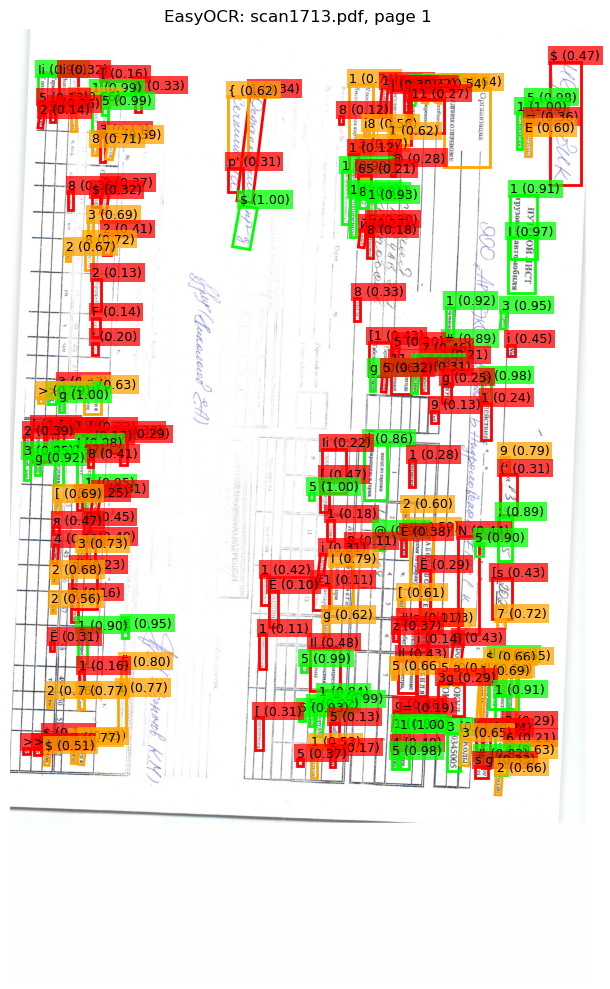

In [15]:
visualize_easyocr_result(scan1713_image, scan1713_easyocr_detections, "EasyOCR: scan1713.pdf, page 1")

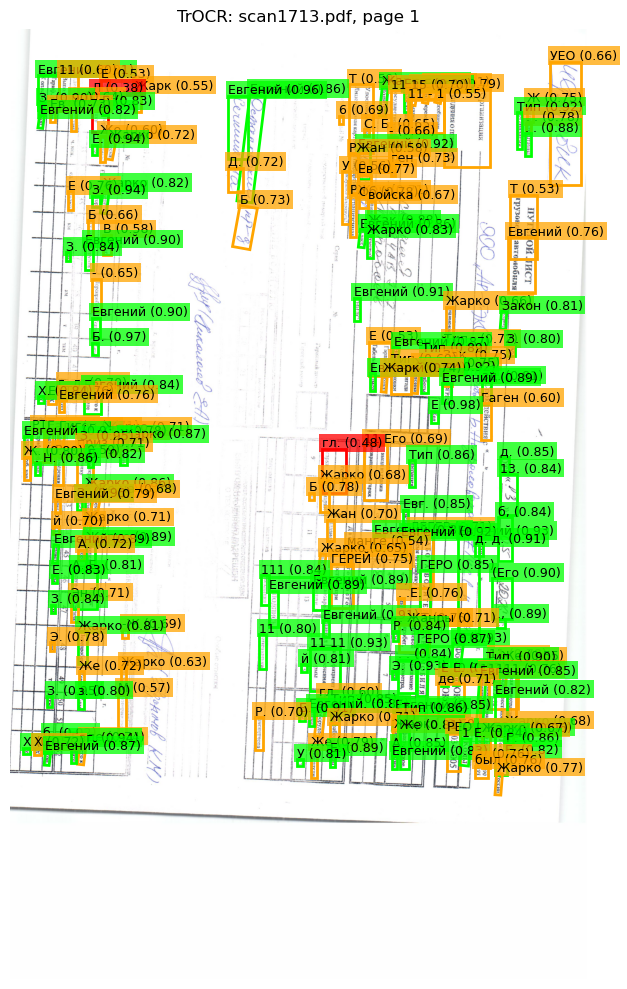

In [16]:
visualize_trocr_result(scan1713_image, scan1713_trocr_rows, "TrOCR: scan1713.pdf, page 1")

In [23]:
scan1713_horisontal_path = Path("Screenshot 2026-05-29 162007.png")
scan1713_horisontal_image = load_pdf_first_page(scan1713_path)
scan1713_horisontal_file_size_kb = os.path.getsize(scan1713_path) / 1024

In [24]:
scan1713_horisontal_easyocr_start = time.perf_counter()
scan1713_horisontal_easyocr_detections = easyocr_reader.readtext(
    np.array(scan1713_horisontal_image),
    detail=1,
    paragraph=False,
)
scan1713_horisontal_easyocr_time = time.perf_counter() - scan1713_horisontal_easyocr_start
scan1713_horisontal_easyocr_detections = sort_detections_reading_order(scan1713_horisontal_easyocr_detections)
scan1713_horisontal_easyocr_text = easyocr_text(scan1713_horisontal_easyocr_detections)

In [25]:
scan1713_horisontal_trocr_start = time.perf_counter()
scan1713_horisontal_trocr_rows = trocr_recognize_detections(scan1713_horisontal_image, scan1713_horisontal_easyocr_detections)
scan1713_horisontal_trocr_time = time.perf_counter() - scan1713_horisontal_trocr_start
scan1713_horisontal_trocr_text = trocr_text(scan1713_horisontal_trocr_rows)

[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

In [26]:
print("Сводка: scan1713_horisontal.pdf, page 1")
print(f"Размер изображения: {scan1713_horisontal_image.width}x{scan1713_horisontal_image.height}px")
print(f"Размер файла: {scan1713_horisontal_file_size_kb:.1f} KB")
print(f"EasyOCR: объектов {len(scan1713_horisontal_easyocr_detections)}, время {scan1713_horisontal_easyocr_time:.2f} с")
print(f"TrOCR: объектов {len(scan1713_horisontal_trocr_rows)}, время {scan1713_horisontal_trocr_time:.2f} с")
print()
print("EasyOCR текст:")
print(scan1713_horisontal_easyocr_text or "[текст не найден]")
print()
print("TrOCR текст:")
print(scan1713_horisontal_trocr_text or "[текст не найден]")

Сводка: scan1713_horisontal.pdf, page 1
Размер изображения: 1870x3080px
Размер файла: 979.8 KB
EasyOCR: объектов 190, время 15.95 с
TrOCR: объектов 190, время 253.04 с

EasyOCR текст:
$
Ii
Ii
[
1
1
11
₽
F
Е
#
|
5
1
1
{
'11
1
5
5
5
g
1
2
8
=
i8
Е
3
1
=
8
3
1
@
p'
1
65
2
8
1
1
$
8
1
$
3
Е
й
2
8
I
8
2
2
8
1
3
F
[1
'
#
i
5
7
i
11
1
2
g
5
8
g
3
#
>
>
g
1
9
[
1
[
[
2
2
1
<
Il
I
Ii
1
3
9
8
1
g
('
[
1
5
=
&
[
2
;
1
₽
я
II
@
N
Ё
Ё
5
4
8
3
i
I
Ё
di
2
1
[s
#1
Ё
3
[
2
7
g
=
#Is
€
1
z
1
Ё
8
i
Il
Il
Il
1
$
5
Ё
1
5
5
а
Ill
1
3g
1
1
2
7
1
#
5
g
5
=
[
5
2
1
1
3
Ё
1
$
3
;
3
6
>
>с
1
4
$
5
4
5
5
#
s g
2

TrOCR текст:
УЕО
Евгений
11
Е
Т
Жарко
.
Е
Е Е
Его
Евг.
11 15
Жарк
Л
Евгений
Евгений
11 - 1
г.
З.
Ж
Б
Ев.
Тип
Евгений
6
. .
С. Б.
. .
Же
-
Жарко
Е.
Евгений
РЖан
ген
Д.
У
Ев
Жарко
Е
Т
РЖан
З.
Об
войска
Б
Б
Жак
Евгений
В
Жарко
Евгений
Евгений
З.
-
Евгений
Жарко
Закон
Евгений
Е
Б.
Тип .
З.
Евгений
Тип
Зак.
Тип
Жарко
Жар.
Евгений
Жарк
зд.
Евгений
г. д.
Евгений
ЕХТ
Х.
Евгений
Гаген
Е
РТЕ
Гали
Гиген
г. Жарко
Ев

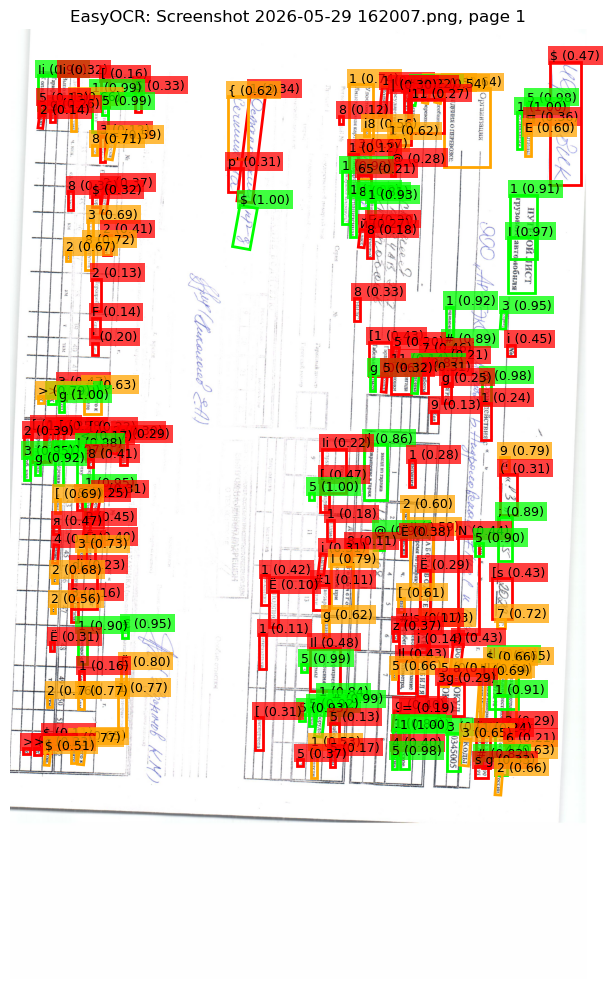

In [27]:
visualize_easyocr_result(scan1713_horisontal_image, scan1713_horisontal_easyocr_detections, "EasyOCR: Screenshot 2026-05-29 162007.png, page 1")

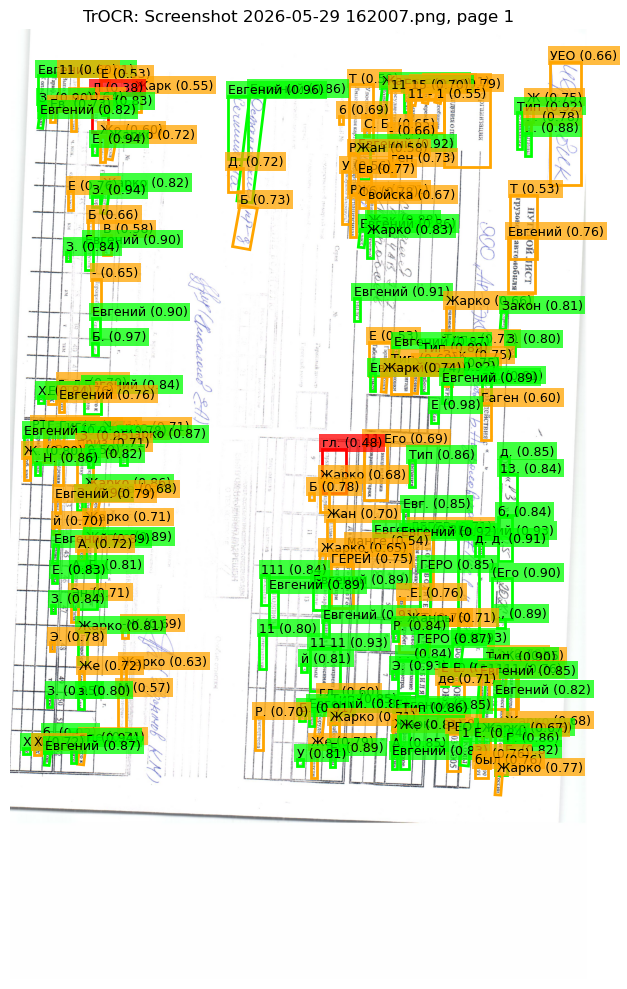

In [28]:
visualize_trocr_result(scan1713_horisontal_image, scan1713_horisontal_trocr_rows, "TrOCR: Screenshot 2026-05-29 162007.png, page 1")

### рукопись.png

In [17]:
handwriting_path = Path("data/рукопись.png")
handwriting_image = Image.open(handwriting_path).convert("RGB")
handwriting_file_size_kb = os.path.getsize(handwriting_path) / 1024

In [18]:
handwriting_easyocr_start = time.perf_counter()
handwriting_easyocr_detections = easyocr_reader.readtext(
    np.array(handwriting_image),
    detail=1,
    paragraph=False,
)
handwriting_easyocr_time = time.perf_counter() - handwriting_easyocr_start
handwriting_easyocr_detections = sort_detections_reading_order(handwriting_easyocr_detections)
handwriting_easyocr_text = easyocr_text(handwriting_easyocr_detections)

In [19]:
handwriting_trocr_start = time.perf_counter()
handwriting_trocr_rows = trocr_recognize_detections(handwriting_image, handwriting_easyocr_detections)
handwriting_trocr_time = time.perf_counter() - handwriting_trocr_start
handwriting_trocr_text = trocr_text(handwriting_trocr_rows)

[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

In [20]:
print("Сводка: рукопись.png")
print(f"Размер изображения: {handwriting_image.width}x{handwriting_image.height}px")
print(f"Размер файла: {handwriting_file_size_kb:.1f} KB")
print(f"EasyOCR: объектов {len(handwriting_easyocr_detections)}, время {handwriting_easyocr_time:.2f} с")
print(f"TrOCR: объектов {len(handwriting_trocr_rows)}, время {handwriting_trocr_time:.2f} с")
print()
print("EasyOCR текст:")
print(handwriting_easyocr_text or "[текст не найден]")
print()
print("TrOCR текст:")
print(handwriting_trocr_text or "[текст не найден]")

Сводка: рукопись.png
Размер изображения: 828x522px
Размер файла: 33.2 KB
EasyOCR: объектов 38, время 2.80 с
TrOCR: объектов 38, время 93.65 с

EasyOCR текст:
Эwoм
cezquMque [iо
8v iwqua
6
meccm
Kwwсaz
Ooбoлho-macu
[сe uwo
weccawa
wat
Kuxe
wUJO:
87.   бaюденuя
~OJbco
<eleq}
cбoucмСеюo wuwcbloM
OquуцuutL
iueqwevouL crogotье dorocwutcectue
wu waweccu e
Ke xомоeм [vwarlwucw
ceouclla   dloxcev)
KoлL "ucмo
eQucibeue
woxceiy %qu
6
'Ч8о
сo
ccмaeeq
кос
#o фbемы oczкж Bowy twOSu
8емсмё
OM
KUX Czaou
flolocom 88 @обюскобея {ефмuя
wuфu
veceKgt
w
ч

TrOCR текст:
Этот
генераторе рука
для примера в
в
текст
написан .
Довольно-таки
Все что
текста.
лисного
ниже,
мило.
для заполнения
только
человеку
свойственно приписывать
окружающим
предметам сказочные, фантастические
или магические
не хватает романтики,
свойства. Может,
нам просто
единственное,
может, вера в
в
чудо
что
остается в
нас
Но цветы заслуживают, чтобы
детства
от
них слагали
Поводом для возникновения предания
мифы
легенды.
и
ма


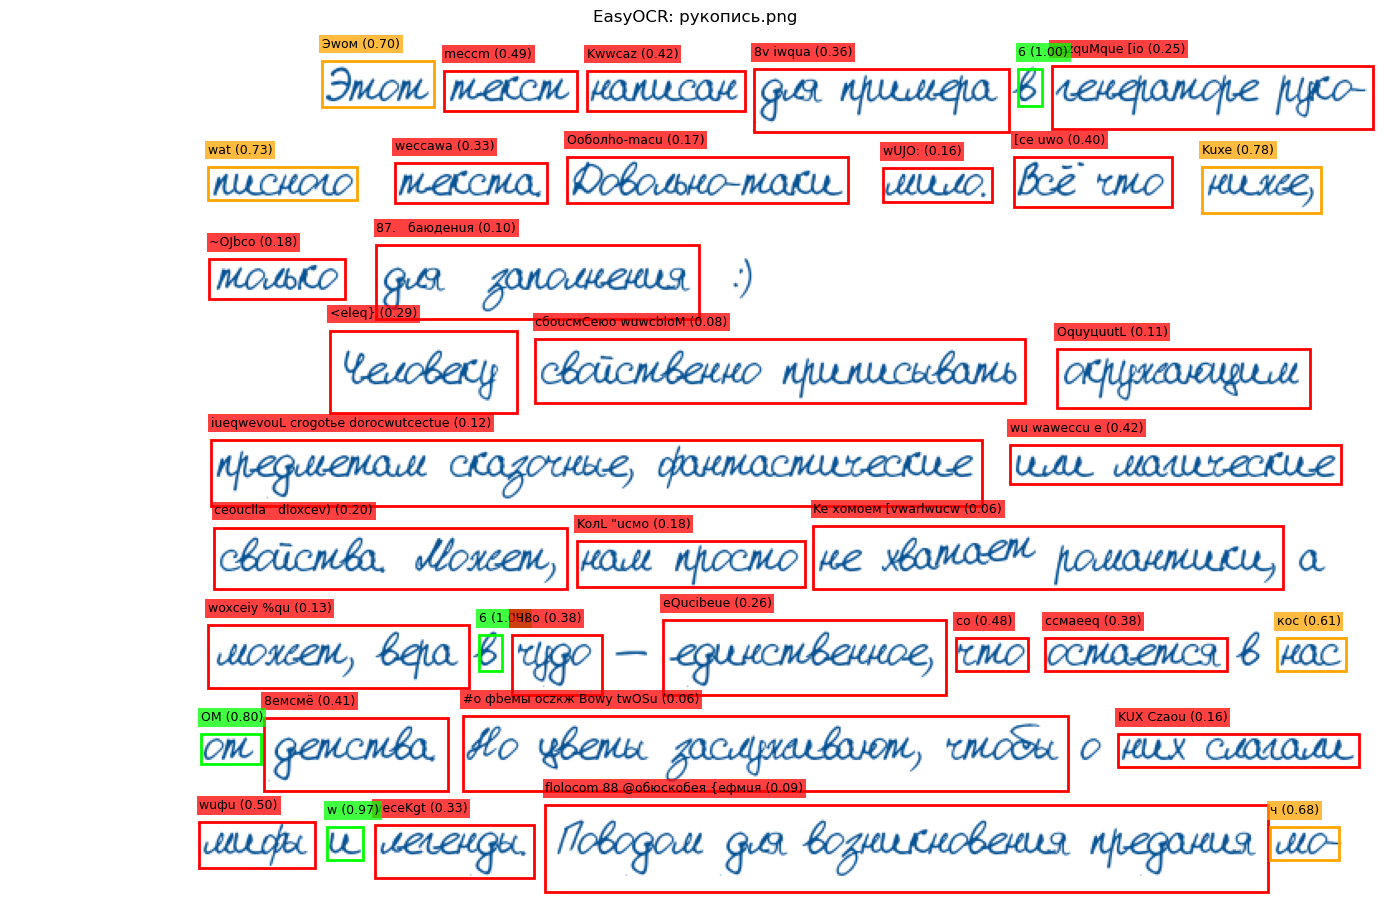

In [21]:
visualize_easyocr_result(handwriting_image, handwriting_easyocr_detections, "EasyOCR: рукопись.png")

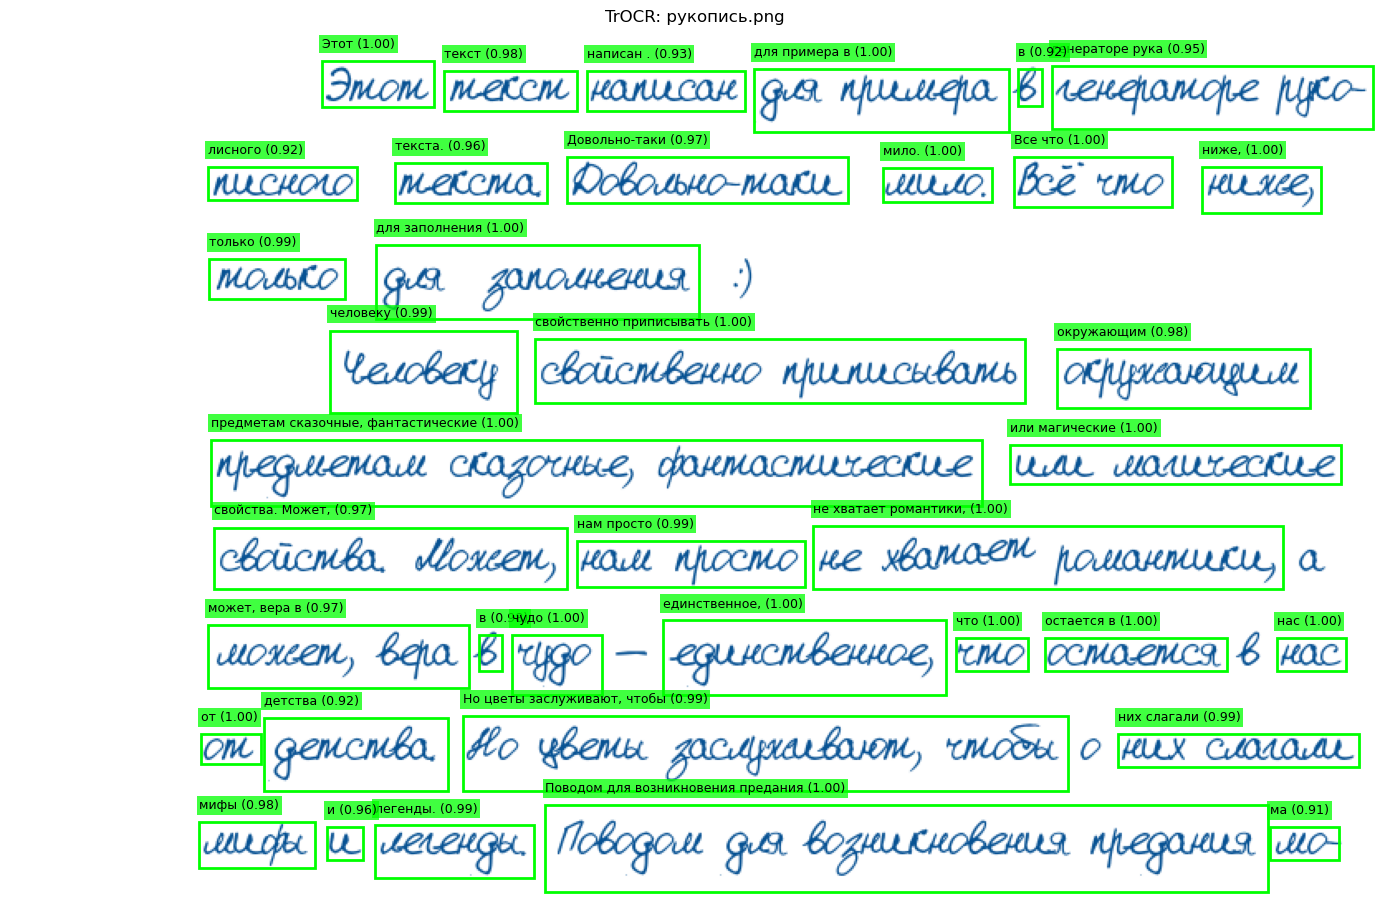

In [22]:
visualize_trocr_result(handwriting_image, handwriting_trocr_rows, "TrOCR: рукопись.png")